# NB04 — Model × Anomaly-Type Recall Matrix

**Main result table** for the MTS Anomaly Taxonomy paper.

Each cell reports **VUS-PR** (Volume Under the Precision-Recall Surface) — the average AUC-PR
integrated over buffer sizes `[0, 5, 10, 20, 50]` timesteps.
Higher = better recall of that anomaly type.

**Expected block structure (hypothesis):**
- Per-channel models (`zscore`, `moving_average`) → high on B2 (trend shifts visible per-channel), low on C-types
- Windowed models (`knn`, `lof`) → partial improvement but still weak on C-types
- Joint models (`mahalanobis`, `covariance`) → strong on C-types (except C2)
- Lag-correlation model → specifically recovers C2 (phase/lag-shift)

In [1]:
from __future__ import annotations

import sys, json
from pathlib import Path

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'font.family': 'sans-serif',
})

RESULTS_DIR = Path('../results')
print('Imports OK')

Imports OK


---
## 1. Load all experiment results

In [2]:
# Priority: use the most recent full run for each model
# recall_matrix JSON has zscore, moving_average, mahalanobis, covariance (full 10 types)
# individual JSONs have knn, lof, lag_correlation (full 10 types from latest run)

def load_latest(model: str) -> dict[str, float]:
    """Return {type: vus_pr} from the latest result file for this model."""
    candidates = sorted(RESULTS_DIR.glob(f'*_{model}.json'), reverse=True)
    if not candidates:
        return {}
    with open(candidates[0]) as f:
        data = json.load(f)
    return data.get('vus_pr', {})

def load_matrix_json() -> dict[str, dict[str, float]]:
    candidates = sorted(RESULTS_DIR.glob('recall_matrix_*.json'), reverse=True)
    if not candidates:
        return {}
    with open(candidates[0]) as f:
        data = json.load(f)
    return data.get('results', {})

# Load
matrix_results = load_matrix_json()   # zscore, moving_average, mahalanobis, covariance
for model in ['knn', 'lof', 'lag_correlation']:
    matrix_results[model] = load_latest(model)

# Verify
for model, scores in sorted(matrix_results.items()):
    print(f'  {model:20s}: {len(scores)} types → {sorted(scores.keys())}')

  covariance          : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  knn                 : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  lag_correlation     : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  lof                 : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  mahalanobis         : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  moving_average      : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']
  zscore              : 10 types → ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']


In [3]:
# Canonical order
MODEL_ORDER = ['zscore', 'moving_average', 'knn', 'lof', 'mahalanobis', 'covariance', 'lag_correlation']
MODEL_LABELS = {
    'zscore':           'Z-Score',
    'moving_average':   'Moving Avg',
    'knn':              'KNN',
    'lof':              'LOF',
    'mahalanobis':      'Mahalanobis',
    'covariance':       'Covariance',
    'lag_correlation':  'LagCorr',
}
# Anomaly types in A/B/C axis order
TYPE_ORDER = ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5']

# Build DataFrame
data = {}
for m in MODEL_ORDER:
    scores = matrix_results.get(m, {})
    data[MODEL_LABELS[m]] = {t: scores.get(t, float('nan')) for t in TYPE_ORDER}

df = pd.DataFrame(data).T   # (n_models, n_types)
df = df[TYPE_ORDER]         # ensure column order

print('\nRecall matrix (VUS-PR):')
print(df.round(3).to_string())


Recall matrix (VUS-PR):
                A1     A2     B1     B2     B3     C1     C2     C3     C4     C5
Z-Score      0.318  0.311  0.303  0.752  0.299  0.310  0.309  0.309  0.312  0.290
Moving Avg   0.318  0.309  0.302  0.389  0.284  0.313  0.310  0.308  0.310  0.289
KNN          0.234  0.216  0.235  0.911  0.230  0.289  0.233  0.255  0.247  0.214
LOF          0.231  0.216  0.229  0.912  0.228  0.275  0.227  0.240  0.238  0.212
Mahalanobis  0.352  0.221  0.971  0.931  0.934  0.993  0.408  0.994  0.982  0.883
Covariance   0.282  0.262  0.267  0.744  0.332  0.607  0.228  0.372  0.345  0.274
LagCorr      0.828  0.741  0.943  0.735  0.959  0.999  0.906  0.978  0.956  0.968


---
## 2. Main heatmap — paper figure

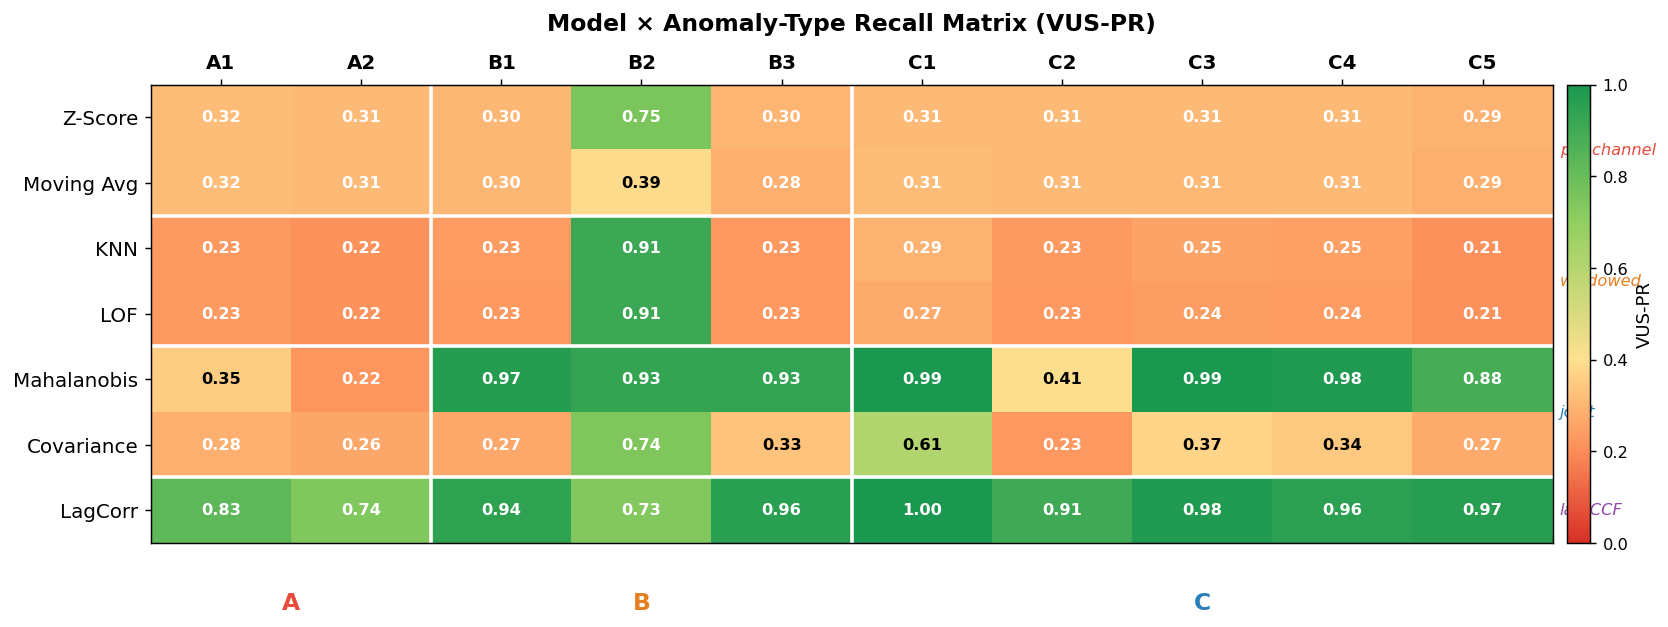

Saved → results/recall_matrix_heatmap.{pdf,png}


In [4]:
# Colour map: white=random(~0.25) → yellow → green=perfect(1.0)
cmap = LinearSegmentedColormap.from_list(
    'recall',
    [(0.0,  '#d73027'),   # low  → red
     (0.2,  '#fc8d59'),
     (0.4,  '#fee090'),   # mid  → yellow
     (0.7,  '#91cf60'),
     (1.0,  '#1a9850')],  # high → green
)

mat = df.values.astype(float)
n_models, n_types = mat.shape

fig, ax = plt.subplots(figsize=(13, 5))

im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0.0, vmax=1.0)

# ── Cell annotations ──────────────────────────────────────────────────────
for i in range(n_models):
    for j in range(n_types):
        v = mat[i, j]
        if not np.isnan(v):
            text_color = 'white' if v > 0.72 or v < 0.32 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')

# ── Axis labels ───────────────────────────────────────────────────────────
ax.set_xticks(range(n_types))
ax.set_xticklabels(TYPE_ORDER, fontsize=11, fontweight='bold')
ax.set_yticks(range(n_models))
ax.set_yticklabels(df.index, fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# ── Anomaly axis bracket annotations (top) ────────────────────────────────
axis_spans = [('A', 0, 1, '#e74c3c'), ('B', 2, 4, '#e67e22'), ('C', 5, 9, '#2980b9')]
for label, col_start, col_end, color in axis_spans:
    mid = (col_start + col_end) / 2
    ax.annotate('', xy=(col_end + 0.45, -1.8), xytext=(col_start - 0.45, -1.8),
                xycoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color=color, lw=2.5))
    ax.text(mid, -0.13, label, transform=ax.get_xaxis_transform(),
            ha='center', va='center', fontsize=13, fontweight='bold', color=color)

# ── Model group separator lines ───────────────────────────────────────────
# Groups: per-channel (0-1), windowed (2-3), joint (4-5), lag (6)
for boundary in [1.5, 3.5, 5.5]:
    ax.axhline(boundary, color='white', lw=2.0)

# ── Model group labels (right side) ───────────────────────────────────────
group_labels = [
    (0.5,  'per-channel', '#e74c3c'),
    (2.5,  'windowed',    '#e67e22'),
    (4.5,  'joint',       '#2980b9'),
    (6.0,  'lag-CCF',     '#8e44ad'),
]
for y, label, color in group_labels:
    ax.text(n_types - 0.45, y, label, va='center', ha='left',
            fontsize=9, color=color, style='italic',
            transform=ax.transData)

# ── Type axis separator (A|B boundary, B|C boundary) ─────────────────────
for boundary in [1.5, 4.5]:
    ax.axvline(boundary, color='white', lw=2.0)

# ── Colorbar ──────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label('VUS-PR', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title(
    'Model × Anomaly-Type Recall Matrix (VUS-PR)',
    fontsize=13, fontweight='bold', pad=30
)

plt.tight_layout()
plt.savefig('../results/recall_matrix_heatmap.pdf', bbox_inches='tight')
plt.savefig('../results/recall_matrix_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → results/recall_matrix_heatmap.{pdf,png}')

---
## 3. Block structure analysis — mean VUS-PR by axis (A / B / C)

Mean VUS-PR by layer axis:
             A (Marginal)  B (Temporal)  C (Inter-met.)
Z-Score             0.315         0.452           0.306
Moving Avg          0.314         0.325           0.306
KNN                 0.225         0.459           0.248
LOF                 0.223         0.457           0.238
Mahalanobis         0.286         0.945           0.852
Covariance          0.272         0.448           0.365
LagCorr             0.785         0.879           0.961



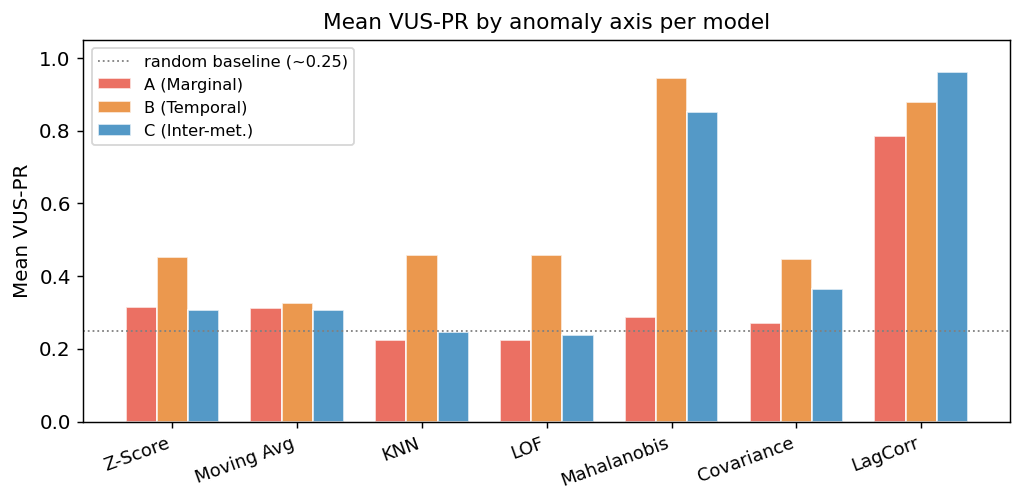

In [5]:
axis_cols = {
    'A (Marginal)':  ['A1', 'A2'],
    'B (Temporal)':  ['B1', 'B2', 'B3'],
    'C (Inter-met.)': ['C1', 'C2', 'C3', 'C4', 'C5'],
}

block_data = {}
for axis_label, cols in axis_cols.items():
    block_data[axis_label] = df[cols].mean(axis=1)
block_df = pd.DataFrame(block_data)

print('Mean VUS-PR by layer axis:')
print(block_df.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(block_df))
width = 0.25
colors = ['#e74c3c', '#e67e22', '#2980b9']

for k, (axis_label, color) in enumerate(zip(axis_cols.keys(), colors)):
    bars = ax.bar(x + k * width, block_df[axis_label], width,
                  label=axis_label, color=color, alpha=0.8, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(block_df.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Mean VUS-PR')
ax.set_ylim(0, 1.05)
ax.axhline(0.25, color='gray', ls=':', lw=1, label='random baseline (~0.25)')
ax.legend(fontsize=9, loc='upper left')
ax.set_title('Mean VUS-PR by anomaly axis per model', fontsize=12)
plt.tight_layout()
plt.savefig('../results/block_structure_bar.png', dpi=180, bbox_inches='tight')
plt.show()

---
## 4. C2 特化 분석 — LagCorrelation vs 기존 모델

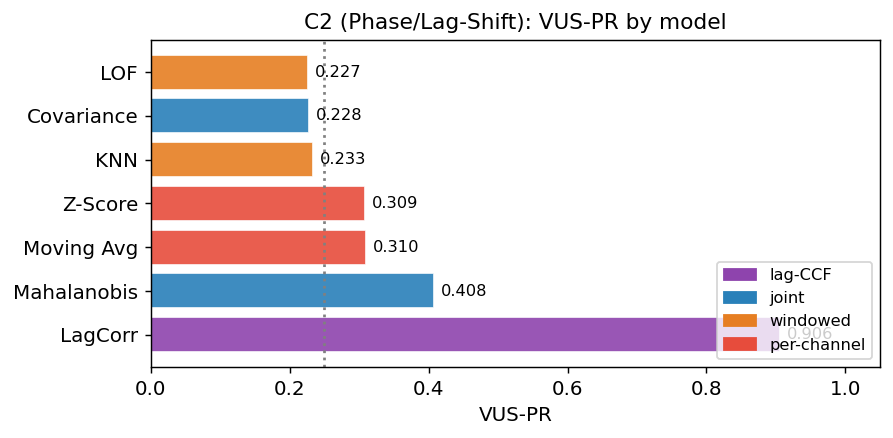

LagCorr C2 gain over best baseline: +0.498


In [6]:
# C2 is the only type all previous models fail; LagCorr should recover it
c2_scores = df['C2'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
bar_colors = ['#8e44ad' if 'Lag' in m else
              '#2980b9' if m in ('Mahalanobis', 'Covariance') else
              '#e67e22' if m in ('KNN', 'LOF') else '#e74c3c'
              for m in c2_scores.index]
bars = ax.barh(range(len(c2_scores)), c2_scores.values,
               color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_yticks(range(len(c2_scores)))
ax.set_yticklabels(c2_scores.index, fontsize=11)
ax.axvline(0.25, color='gray', ls=':', lw=1.5, label='random baseline')
ax.set_xlabel('VUS-PR')
ax.set_xlim(0, 1.05)
ax.set_title('C2 (Phase/Lag-Shift): VUS-PR by model', fontsize=12)

# Value labels
for i, v in enumerate(c2_scores.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#8e44ad', label='lag-CCF'),
    mpatches.Patch(color='#2980b9', label='joint'),
    mpatches.Patch(color='#e67e22', label='windowed'),
    mpatches.Patch(color='#e74c3c', label='per-channel'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../results/c2_analysis.png', dpi=180, bbox_inches='tight')
plt.show()

print(f"LagCorr C2 gain over best baseline: "
      f"+{c2_scores['LagCorr'] - c2_scores.drop('LagCorr').max():.3f}")

---
## 5. Per-type ranking — which model wins each type?

In [7]:
print('Best model per anomaly type:')
print('-' * 42)
for atype in TYPE_ORDER:
    col = df[atype].dropna()
    best_model = col.idxmax()
    best_score = col.max()
    second_model = col.drop(best_model).idxmax()
    second_score = col.drop(best_model).max()
    print(f'  {atype}: {best_model:15s} {best_score:.3f}  '
          f'(2nd: {second_model:15s} {second_score:.3f})')

Best model per anomaly type:
------------------------------------------
  A1: LagCorr         0.828  (2nd: Mahalanobis     0.352)
  A2: LagCorr         0.741  (2nd: Z-Score         0.311)
  B1: Mahalanobis     0.971  (2nd: LagCorr         0.943)
  B2: Mahalanobis     0.931  (2nd: LOF             0.912)
  B3: LagCorr         0.959  (2nd: Mahalanobis     0.934)
  C1: LagCorr         0.999  (2nd: Mahalanobis     0.993)
  C2: LagCorr         0.906  (2nd: Mahalanobis     0.408)
  C3: Mahalanobis     0.994  (2nd: LagCorr         0.978)
  C4: Mahalanobis     0.982  (2nd: LagCorr         0.956)
  C5: LagCorr         0.968  (2nd: Mahalanobis     0.883)


In [8]:
print('\nKey findings:')
print('─' * 60)

# C-type gap
per_ch_models = ['Z-Score', 'Moving Avg']
joint_models  = ['Mahalanobis', 'Covariance']
c_types = ['C1', 'C2', 'C3', 'C4', 'C5']

per_ch_c = df.loc[per_ch_models, c_types].mean().mean()
joint_c  = df.loc[joint_models,  c_types].mean().mean()
lagcorr_c = df.loc['LagCorr', c_types].mean()

print(f'  Mean C-type VUS-PR:')
print(f'    Per-channel models:  {per_ch_c:.3f}')
print(f'    Joint models:        {joint_c:.3f}  (+{joint_c - per_ch_c:.3f})')
print(f'    LagCorr:             {lagcorr_c:.3f}  (+{lagcorr_c - per_ch_c:.3f})')

# C2 specific
print(f'\n  C2 (Phase/Lag-Shift):')
print(f'    Best joint model:    {df.loc[joint_models, "C2"].max():.3f}')
print(f'    LagCorr:             {df.loc["LagCorr", "C2"]:.3f}')
c2_gain = df.loc['LagCorr', 'C2'] - df.loc[joint_models, 'C2'].max()
print(f'    LagCorr gain:        +{c2_gain:.3f} (relative: {c2_gain / df.loc[joint_models, "C2"].max() * 100:.0f}%)')

# A-type weakness
a_types = ['A1', 'A2']
all_a = df[a_types].max(axis=1)
print(f'\n  A-type (marginal) — best model per type:')
for t in a_types:
    best = df[t].idxmax()
    print(f'    {t}: {best} = {df[t].max():.3f}')


Key findings:
────────────────────────────────────────────────────────────
  Mean C-type VUS-PR:
    Per-channel models:  0.306
    Joint models:        0.609  (+0.303)
    LagCorr:             0.961  (+0.655)

  C2 (Phase/Lag-Shift):
    Best joint model:    0.408
    LagCorr:             0.906
    LagCorr gain:        +0.498 (relative: 122%)

  A-type (marginal) — best model per type:
    A1: LagCorr = 0.828
    A2: LagCorr = 0.741


---
## 6. Radar chart — model capability profile

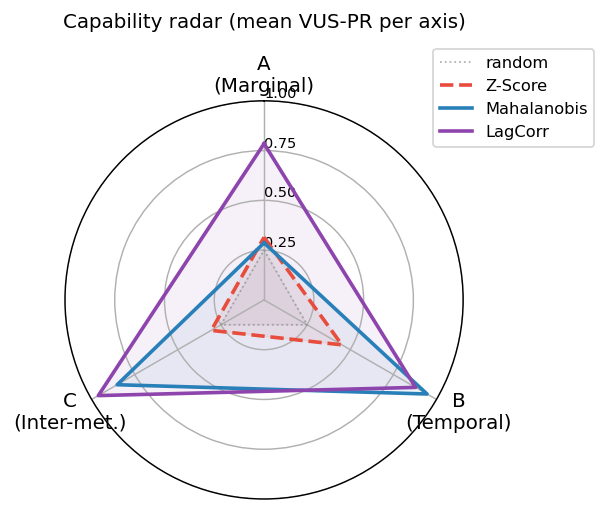

In [9]:
from matplotlib.patches import FancyArrowPatch

# Use axis-mean scores for a compact capability radar
radar_axes = list(axis_cols.keys())
N = len(radar_axes)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

plot_models = {
    'Z-Score':      ('#e74c3c', '--'),
    'Mahalanobis':  ('#2980b9', '-'),
    'LagCorr':      ('#8e44ad', '-'),
}

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlim(0, 1)
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_rlabel_position(0)
ax.tick_params(labelsize=8)
ax.set_xticks(angles[:-1])
short_labels = ['A\n(Marginal)', 'B\n(Temporal)', 'C\n(Inter-met.)']
ax.set_xticklabels(short_labels, fontsize=11)

# Random-chance reference circle
ref = [0.25] * N + [0.25]
ax.plot(angles, ref, color='gray', lw=1, ls=':', alpha=0.6, label='random')
ax.fill(angles, ref, color='gray', alpha=0.08)

for model, (color, ls) in plot_models.items():
    values = [block_df.loc[model, ax_lbl] for ax_lbl in radar_axes]
    values += values[:1]
    ax.plot(angles, values, color=color, lw=2, ls=ls, label=model)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_title('Capability radar (mean VUS-PR per axis)', fontsize=11, pad=15)

plt.tight_layout()
plt.savefig('../results/capability_radar.png', dpi=180, bbox_inches='tight')
plt.show()

---
## 7. Summary table — LaTeX ready

In [10]:
# Format: bold the best value in each column
def bold_max(col):
    max_val = col.max()
    return [f'\\textbf{{{v:.3f}}}' if v == max_val else f'{v:.3f}' for v in col]

df_latex = df.copy()
for col in df_latex.columns:
    df_latex[col] = bold_max(df_latex[col])

latex = df_latex.to_latex(
    caption='Model $\\times$ Anomaly-Type Recall Matrix (VUS-PR). '
            'Bold = best per column. '
            'Buffer sizes $b \\in \\{0,5,10,20,50\\}$.',
    label='tab:recall_matrix',
    escape=False,
    column_format='l' + 'r' * len(TYPE_ORDER),
)
print(latex)

with open('../results/recall_matrix_table.tex', 'w') as f:
    f.write(latex)
print('Saved → results/recall_matrix_table.tex')

\begin{table}
\caption{Model $\times$ Anomaly-Type Recall Matrix (VUS-PR). Bold = best per column. Buffer sizes $b \in \{0,5,10,20,50\}$.}
\label{tab:recall_matrix}
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & A1 & A2 & B1 & B2 & B3 & C1 & C2 & C3 & C4 & C5 \\
\midrule
Z-Score & 0.318 & 0.311 & 0.303 & 0.752 & 0.299 & 0.310 & 0.309 & 0.309 & 0.312 & 0.290 \\
Moving Avg & 0.318 & 0.309 & 0.302 & 0.389 & 0.284 & 0.313 & 0.310 & 0.308 & 0.310 & 0.289 \\
KNN & 0.234 & 0.216 & 0.235 & 0.911 & 0.230 & 0.289 & 0.233 & 0.255 & 0.247 & 0.214 \\
LOF & 0.231 & 0.216 & 0.229 & 0.912 & 0.228 & 0.275 & 0.227 & 0.240 & 0.238 & 0.212 \\
Mahalanobis & 0.352 & 0.221 & \textbf{0.971} & \textbf{0.931} & 0.934 & 0.993 & 0.408 & \textbf{0.994} & \textbf{0.982} & 0.883 \\
Covariance & 0.282 & 0.262 & 0.267 & 0.744 & 0.332 & 0.607 & 0.228 & 0.372 & 0.345 & 0.274 \\
LagCorr & \textbf{0.828} & \textbf{0.741} & 0.943 & 0.735 & \textbf{0.959} & \textbf{0.999} & \textbf{0.906} & 0.978 & 0.956 & \textbf{0.968} \\
\bott